# Swin Transformer

## Goal

The purpose of this notebook is to demonstrate the key ideas behind the Swin Transformer architecture.

Unlike Vision Transformers (ViT), Swin Transformer performs self-attention inside local windows and uses shifted windows to exchange information between neighboring regions.

This makes Swin Transformer more computationally efficient while maintaining strong performance.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Local Windows

Swin Transformer divides an image into local windows.

Self-attention is performed only inside each window instead of across the entire image.

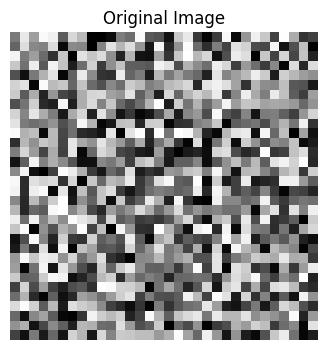

In [2]:
image = np.random.rand(32, 32)

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

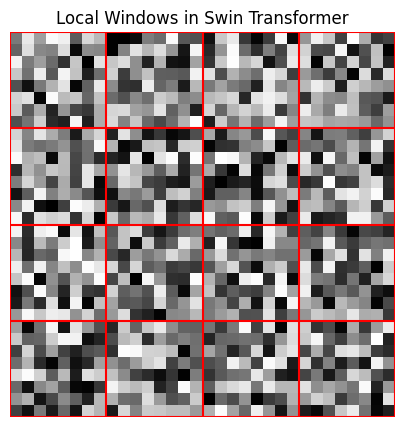

In [3]:
window_size = 8

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap="gray")

for i in range(0, 33, window_size):
    plt.axhline(i - 0.5, color="red")

for j in range(0, 33, window_size):
    plt.axvline(j - 0.5, color="red")

plt.title("Local Windows in Swin Transformer")
plt.axis("off")
plt.show()

## Shifted Windows

Instead of attending to all image patches, Swin Transformer performs self-attention inside local windows.

After each stage, the windows are shifted, allowing information exchange between neighboring regions.

This reduces computational cost while preserving global context.

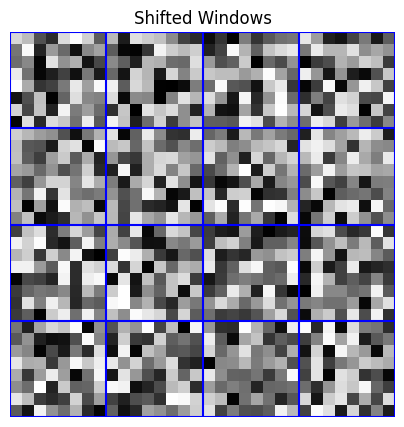

In [4]:
shifted_image = np.roll(image, shift=4, axis=0)
shifted_image = np.roll(shifted_image, shift=4, axis=1)

plt.figure(figsize=(5, 5))
plt.imshow(shifted_image, cmap="gray")

for i in range(0, 33, window_size):
    plt.axhline(i - 0.5, color="blue")

for j in range(0, 33, window_size):
    plt.axvline(j - 0.5, color="blue")

plt.title("Shifted Windows")
plt.axis("off")
plt.show()

## Loading a Pretrained Swin Transformer

We can load a pretrained Swin Transformer model from Hugging Face.

The model uses local self-attention inside windows and shifted windows between stages.

In [5]:
from transformers import SwinModel

swin = SwinModel.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224"
)

print(type(swin))

config.json:   0%|          | 0.00/71.8k [00:00<?, ?B/s]

c:\Users\teter\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\teter\.cache\huggingface\hub\models--microsoft--swin-tiny-patch4-window7-224. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

[transformers] SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<class 'transformers.models.swin.modeling_swin.SwinModel'>


## Counting Parameters

Let's inspect how many parameters the Swin Transformer contains.

In [6]:
swin_params = sum(
    p.numel()
    for p in swin.parameters()
)

print(f"Total parameters: {swin_params:,}")

Total parameters: 27,519,354


## Comparing Vision Transformer and Swin Transformer

Vision Transformer applies global self-attention across all image patches.

Swin Transformer restricts attention to local windows and introduces shifted windows between layers.

This significantly reduces computational complexity while still allowing information to flow across the entire image.

As a result, Swin Transformer is often more efficient than a standard Vision Transformer.

In [7]:
print(f"ResNet18 parameters: {11_689_512:,}")
print(f"Swin Tiny parameters: {swin_params:,}")
print(f"ViT Base parameters: {86_389_248:,}")

ResNet18 parameters: 11,689,512
Swin Tiny parameters: 27,519,354
ViT Base parameters: 86,389,248


## Conclusion

In this notebook we explored the main ideas behind the Swin Transformer architecture.

We:

- Visualized local windows
- Demonstrated shifted windows
- Loaded a pretrained Swin Transformer model
- Counted model parameters
- Compared Swin Transformer with Vision Transformer and ResNet18

Swin Transformer combines the flexibility of Transformers with a more efficient attention mechanism, making it one of the most influential computer vision architectures.